# **1. Python ile Veri Görselleştirme (Tips Veri Seti)**

Bu derste, Python kullanarak veri görselleştirme tekniklerini uygulamalı olarak öğreneceğiz. Restoran bahşiş veri seti (tips.csv) üzerinden
veri setinin yüklenmesi, sütun isimlerinin Türkçeleştirilmesi, veri tiplerinin düzenlenmesi ve çeşitli grafiklerin (çizgi, bar, scatter, histogram, pasta) oluşturulması adımlarını inceleyeceğiz.

## 1.1 **Google Drive Bağlantısı ve Kütüphane Yükleme**

**Açıklama (Mark):**  
- Google Drive'daki veri setlerine erişebilmek için Drive'ı bağlamamız gerekir (Colab kullanıyorsanız).  
- Gerekli Python kütüphaneleri yüklenip içe aktarılır.  
- Bu kod bloğu, temel kütüphanelerin kurulumunu ve içe aktarılmasını gösterir.  

###  Kullanılan Kütüphaneler ve Açıklamaları:
- **`numpy`**  Sayısal hesaplamalar ve matris işlemleri için kullanılır.
- **`pandas`**  Veri işleme, analiz ve veri çerçeveleri ile çalışma imkanı sunar.
- **`matplotlib`**  Grafik ve veri görselleştirme için temel kütüphanelerden biridir.
- **`seaborn`**  Daha gelişmiş ve estetik veri görselleştirme için matplotlib'in üzerine inşa edilmiştir.
**`sklearn`**  (scikit-learn)  Veri ön işleme, modelleme ve değerlendirme araçları içerir.
- **`yellowbrick`**  Makine öğrenmesi modellerinin görselleştirilmesini sağlayan bir kütüphane.

 **Bu kütüphaneler, veri analizi ve modelleme süreçlerinde sıkça kullanılır.**

In [1]:
# Gerekli kütüphanelerin yüklenmesi
!pip install -q numpy pandas scikit-learn matplotlib seaborn yellowbrick

# Kütüphanelerin içeri aktarılması
import numpy as np                # Sayısal hesaplamalar ve diziler için
import pandas as pd               # Veri çerçeveleri ile çalışmak için
import matplotlib.pyplot as plt   # Grafik çizimi için
import seaborn as sns             # Gelişmiş veri görselleştirme için

# Ek modüller ve sklearn fonksiyonları
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             silhouette_score)
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn import datasets     # Veri ön işleme, modelleme ve değerlendirme araçları


from google.colab import drive
drive.mount('/content/drive')       #Google Drive'a bağlanmamızı sağlar (Colab).

[Colab Compat] Drive mounted (local mode) -> /Users/zuber/INP214


## **1.2 Tips (Bahşiş) Veri Setinin Yüklenmesi ve Temel İşlemler**

- Google Drive'da bulunan `tips.csv` dosyası okunacaktır.
- Veri setinin sütun isimleri İngilizce'den Türkçe'ye çevrilecek (ör. `total_bill` → `toplamHesap`, `tip` → `bahsis`, vb.).
- Kategorik sütunların veri tipi `category` olarak ayarlanacak.
- Kategorik değerler güncellenecek (örneğin, "Male" → "erkek").
- Son olarak, veri setinin özet istatistikleri alınarak veri yapısı kontrol edilecektir.

## **1.2.1 Veri Setini Okuma**

In [2]:
# Veri setini Google Drive'dan okuyoruz
# Pandas DataFrame formatına çeviriyoruz
# ve 'tips_df' isimli değişkene atıyoruz
tips_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tips.csv')

# 'dtypes' Her sutunun veri tipini gösterir
print(tips_df.dtypes)


# İlk 5 satırı görüntüleyerek veri setine göz atalım
display(tips_df.head())

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## **1.2.2 Sütun İsimlerini Türkçeleştirme**

In [3]:
# İngilizce sütun isimlerini Türkçeye çeviriyoruz
# DataFrame.rename(columns={...}): Sütun adlarını değiştirmemizi sağlar.

tips_df = tips_df.rename(columns={
    "total_bill": "toplamHesap",
    "tip": "bahsis",
    "sex": "cinsiyet",
    "smoker": "sigaraDurum",
    "day": "gun",
    "time": "ogun",
    "size": "kisiSayisi"
})

# Değişiklikleri doğrulamak için ilk 5 satırı tekrar gözlemleyelim
tips_df.head()

,toplamHesap,bahsis,cinsiyet,sigaraDurum,gun,ogun,kisiSayisi
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## **1.2.3 `object` Kategorik Sütunları --> `category` Veri Tipine Dönüştürme**

## Neden `"category"` Veri Tipine Dönüştürüyoruz?

###  Bellek Kullanımını Azaltır  
- **`object` veri tipi**, her hücre için ayrı ayrı metin (string) saklar ve fazla yer kaplar.  
- **`category` tipi**, tekrar eden değerleri hafızada tek bir kez saklayarak **daha az bellek kullanır**.

###  İşlem Verimliliğini Artırır
- Makine öğrenmesi ve veri analizi işlemlerinde kategorik değişkenler genellikle **nümerik olarak işlenir**.  
- **`category` veri tipi**, işlemleri hızlandırır çünkü **daha hızlı karşılaştırma ve gruplama yapabilir**.

###  Veri Analizini Kolaylaştırır  
- Kategorik değişkenlerin **sınıflarını** (`.cat.categories`) ve **frekanslarını** (`.value_counts()`) daha kolay analiz edebilirsin.  

### **İlk Veri Tipleri** Kontrol Etme

In [4]:
# Sütunların ilk veri tiplerini Kontrol etme
print("İlk veri tipleri:")

#DataFrame.dtypes: Her sütunun veri tipini (int, float, object vs.) gösterir.
print(tips_df.dtypes)

İlk veri tipleri:
toplamHesap    float64
bahsis         float64
cinsiyet           str
sigaraDurum        str
gun                str
ogun               str
kisiSayisi       int64
dtype: object


### **Dönüştürme İşlemi ve Sonrası Veri Tipleri** Kontrol Etme

In [5]:
# `astype('category')`: Nesnel (object) tipindeki sütunları kategorik tipine çevirerek
# bellek kullanımını ve işlem verimliliğini artırır.

tips_df["cinsiyet"] = tips_df["cinsiyet"].astype("category")
tips_df["sigaraDurum"] = tips_df["sigaraDurum"].astype("category")
tips_df["gun"] = tips_df["gun"].astype("category")
tips_df["ogun"] = tips_df["ogun"].astype("category")

# Dönüşüm sonrası veri tiplerini kontrol etmek için:
print("\nDönüştürme sonrası veri tipleri:")
print(tips_df.dtypes)


Dönüştürme sonrası veri tipleri:
toplamHesap     float64
bahsis          float64
cinsiyet       category
sigaraDurum    category
gun            category
ogun           category
kisiSayisi        int64
dtype: object


## **1.2.4 Kategorik Değerleri Güncelleme (İngilizce → Türkçe)**
- `.cat.rename_categories({...})`: Kategorik sütun değerlerini yeniden adlandırır.

In [6]:
# Kategorik değerlerin Türkçeleştirilmesi
# .cat.rename_categories(): Kategori isimlerini yeniden adlandırmak için kullanılır
tips_df["cinsiyet"] = tips_df["cinsiyet"].cat.rename_categories({"Male": "erkek", "Female": "kadin"})
tips_df["sigaraDurum"] = tips_df["sigaraDurum"].cat.rename_categories({"No": "hayir", "Yes": "evet"})
tips_df["gun"] = tips_df["gun"].cat.rename_categories({
    "Sun": "pazar", "Sat": "cumartesi", "Thur": "persembe", "Fri": "cuma"
})
tips_df["ogun"] = tips_df["ogun"].cat.rename_categories({"Lunch": "ogle", "Dinner": "aksam"})

# Değişiklikleri görmek için
tips_df.head(10)

,toplamHesap,bahsis,cinsiyet,sigaraDurum,gun,ogun,kisiSayisi
0,16.99,1.01,kadin,hayir,pazar,aksam,2
1,10.34,1.66,erkek,hayir,pazar,aksam,3
2,21.01,3.50,erkek,hayir,pazar,aksam,3
3,23.68,3.31,erkek,hayir,pazar,aksam,2
4,24.59,3.61,kadin,hayir,pazar,aksam,4
5,25.29,4.71,erkek,hayir,pazar,aksam,4
6,8.77,2.00,erkek,hayir,pazar,aksam,2
7,26.88,3.12,erkek,hayir,pazar,aksam,4
8,15.04,1.96,erkek,hayir,pazar,aksam,2
9,14.78,3.23,erkek,hayir,pazar,aksam,2


## **1.3 Veri Setinin Özet İstatistikleri**

In [7]:
print("\nSayısal özet (describe):")

# describe(): Sayısal sütunlar için istatistiksel özet (ortalama, std, min, max vb.) verir.
print(tips_df.describe())

pd.set_option("display.max_columns", 20)
print("\nTüm sütun özet bilgisi:")
# describe(include='all'): Kategorik sütunları da özetleyerek benzersiz değer sayısı,
# en sık görülen değer vb. bilgileri gösterir.
print(tips_df.describe(include="all"))


Sayısal özet (describe):
       toplamHesap      bahsis  kisiSayisi
count   244.000000  244.000000  244.000000
mean     19.785943    2.998279    2.569672
std       8.902412    1.383638    0.951100
min       3.070000    1.000000    1.000000
25%      13.347500    2.000000    2.000000
50%      17.795000    2.900000    2.000000
75%      24.127500    3.562500    3.000000
max      50.810000   10.000000    6.000000

Tüm sütun özet bilgisi:
        toplamHesap      bahsis cinsiyet sigaraDurum        gun   ogun  \
count    244.000000  244.000000      244         244        244    244   
unique          NaN         NaN        2           2          4      2   
top             NaN         NaN    erkek       hayir  cumartesi  aksam   
freq            NaN         NaN      157         151         87    176   
mean      19.785943    2.998279      NaN         NaN        NaN    NaN   
std        8.902412    1.383638      NaN         NaN        NaN    NaN   
min        3.070000    1.000000      NaN    

## **1.3 Veri Setinin İstatistik Açıklamaları**

###  **Toplam Hesap Dağılımı:**
- **En düşük hesap:** 3.07$  
- **En yüksek hesap:** 50.81$  
- **Ortalama hesap:** ~19.79$  
- **Standart sapma:** ~8.90$  
   **Müşterilerin büyük çoğunluğu (~%68) 10.89$ ile 28.69$ arasında hesap ödemektedir.**  

---

###  **Bahşiş Dağılımı:**
- **En düşük bahşiş:** 1.00$  
- **En yüksek bahşiş:** 10.00$  
- **Ortalama bahşiş:** ~3.00$  
- **Standart sapma:** ~1.38$  
   **Müşterilerin büyük çoğunluğu (~%68) 1.62$ ile 4.38$ arasında bahşiş bırakmaktadır.**  

---

###  **Kişi Sayısı:**
- **Minimum kişi sayısı:** 1  
- **Maksimum kişi sayısı:** 6  
- **Ortalama kişi sayısı:** ~2.57  
   **Masaların çoğu 2-3 kişiliktir.**  

---

###  **Cinsiyet Dağılımı:**
- **Erkek müşteri sayısı:** 157  
- **Kadın müşteri sayısı:** 87  
   **Müşterilerin %64'ü erkektir.**  

---

###  **Sigara İçme Durumu:**
- **Sigara içmeyen müşteri sayısı:** 151  
- **Sigara içen müşteri sayısı:** 93  
   **Müşterilerin %62'si sigara içmiyor.**  

---

###  **Gün Dağılımı:**
- **En yoğun gün:** Cumartesi (*cumartesi*) — **87 müşteri**  
- **Diğer günler:** Pazar (76), Perşembe (62), Cuma (19)  
   **Hafta sonu günleri (Cumartesi ve Pazar) en yoğun zamanlardır.**  

---

###  **Öğün Dağılımı:**
- **Akşam yemeği müşteri sayısı:** 176  
- **Öğle yemeği müşteri sayısı:** 68  
   **Müşterilerin %72'si akşam yemeğinde gelmektedir.**  

## **1.4 Veri Görselleştirme (Tips)**

### **1.4.1 Çizgi Grafik (Line Plot)**

**Örnek 1:** İlk 20 müşterinin bahşiş değerlerini çizgi grafik ile görselleştirme.

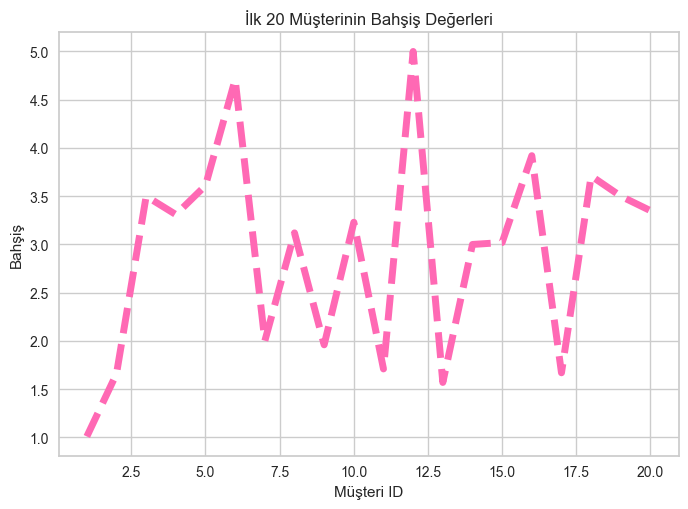

In [8]:
x_line = np.arange(1, 21)  # Müşteri ID'leri 1'den 20'ye
y_line = tips_df.iloc[0:20, 1]  # İlk 20 müşterinin bahşiş sütunu (index 1)

plt.figure()
plt.plot(x_line, y_line, linestyle="dashed", color="hotpink", linewidth=5)
plt.title("İlk 20 Müşterinin Bahşiş Değerleri")
plt.xlabel("Müşteri ID")
plt.ylabel("Bahşiş")
plt.show()

**Örnek 2:** 40-60. Müşterilerin Toplam Hesap Dağılımı

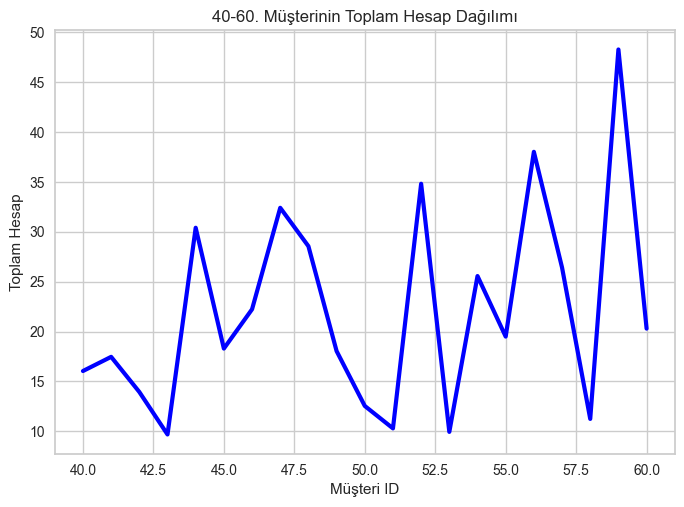

In [9]:
x_line = np.arange(40, 61)
y_line = tips_df.iloc[40:61, 0]  # Dizi boyutunu eşitlemek için 40:61 kullanıldı

plt.figure()
plt.plot(x_line, y_line, color="blue", linewidth=3)
plt.title("40-60. Müşterinin Toplam Hesap Dağılımı")
plt.xlabel("Müşteri ID")
plt.ylabel("Toplam Hesap")

plt.show()

**Örnek 3:** İlk 20 ile 21-40 arasındaki müşterilerin bahşiş değerlerinin karşılaştırılması.

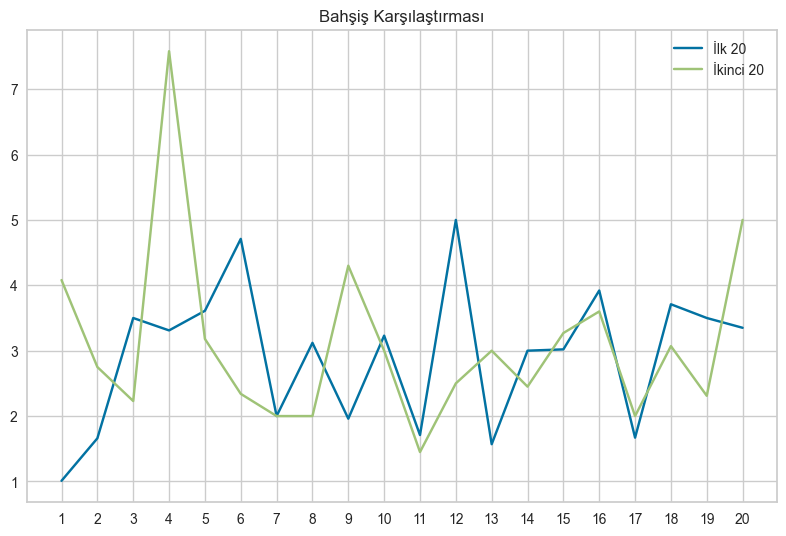

In [10]:
x_line2 = np.arange(1, 21)        # X ekseni için 1'den 20'ye kadar olan değerleri içeren bir NumPy dizisi oluşturuluyor
y1 = tips_df.iloc[0:20, 1]        # İlk 20 müşterinin 1. sütundaki (bahşiş) verisini al
y2 = tips_df.iloc[20:40, 1]       # Sonraki 20 müşterinin 1. sütundaki verisini al (21-40. satırlar)

plt.figure()                      # Yeni bir grafik figürü oluştur

plt.xticks(x_line2)               # X ekseninde 1'den 20'ye kadar olan tam sayıları göster
plt.plot(x_line2, y1, label="İlk 20")  # İlk 20 müşteri için çizgi grafiği oluştur
plt.plot(x_line2, y2, label="İkinci 20")  # İkinci 20 müşteri için çizgi grafiği oluştur

plt.title("Bahşiş Karşılaştırması")  # Grafiğe başlık ekle
plt.legend()                      # Çizgilerin hangi gruba ait olduğunu gösteren bir açıklama (legend) ekle
plt.tight_layout(pad=1)           # Grafik düzenini optimize ederek kenar boşluklarını ayarla
plt.show()                        # Grafiği ekrana bastır

**Örnek 4:** İlk 50 müşterinin toplam hesap dağılımının çizgi grafiği.

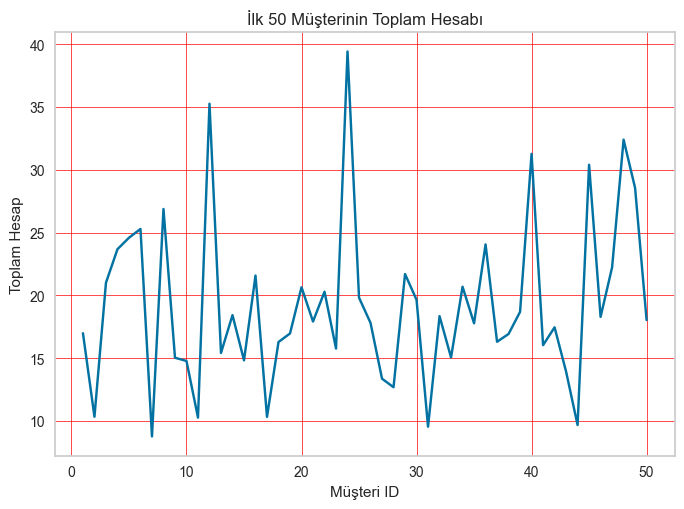

In [11]:
x_bill = np.arange(1, 51)            # 1'den 50'ye kadar müşteri ID'lerini içeren NumPy dizisi oluştur
y_bill = tips_df.iloc[0:50, 0]       # İlk 50 müşterinin toplam hesap bilgilerini içeren sütunu seç (0. sütun)

plt.figure()                          # Yeni bir grafik figürü oluştur
plt.title("İlk 50 Müşterinin Toplam Hesabı") # Grafiğe başlık ekle
plt.xlabel("Müşteri ID")             # X ekseni etiketi (Müşteri ID'leri)
plt.ylabel("Toplam Hesap")           # Y ekseni etiketi (Müşterilerin toplam hesabı)

plt.plot(x_bill, y_bill)              # Müşteri ID'lerine karşılık gelen toplam hesabı çizgi grafiği olarak çiz
plt.grid(color="red", linestyle="solid", linewidth=0.5)  # Grafiğe kırmızı renkli ve ince bir ızgara çizgisi ekle

plt.show()

### **1.4.2 Bar Grafikleri**

**Örnek 1:** Sigara içme durumuna göre ortalama bahşiş miktarının bar grafiği.

Index(['toplamHesap', 'bahsis', 'cinsiyet', 'sigaraDurum', 'gun', 'ogun',
       'kisiSayisi'],
      dtype='str')


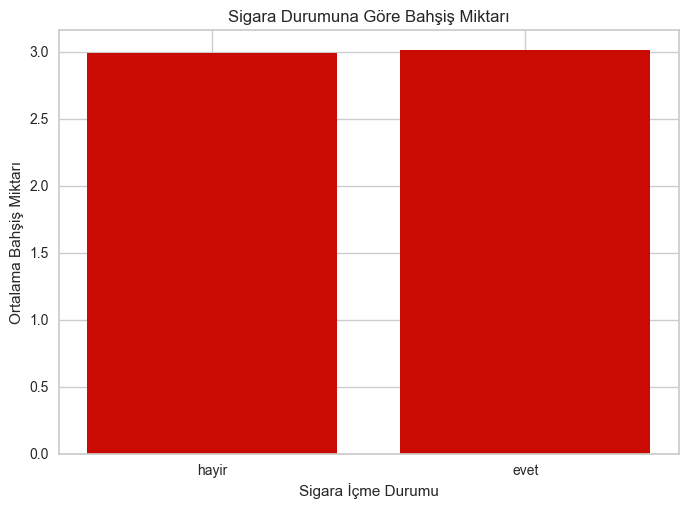

In [12]:
# Sigara içme durumuna göre ortalama bahşiş miktarını hesapla
print(tips_df.columns)
ozet = tips_df.groupby("sigaraDurum", observed=True)["bahsis"].mean()
        # - 'groupby("sigaraDurum")'  Veriyi "sigara içme durumu" sütununa göre gruplar.
        # - '["bahsis"].mean()'  Her grup için bahşiş miktarının ortalamasını alır.

plt.figure()  # Yeni bir grafik figürü oluştur

plt.bar(x=ozet.index, height=ozet.values, color="r")
        # Dikey çubuk grafiği çiz
        # - 'x=ozet.index'  Çubukların kategorik değerleri (sigara içen/içmeyen).
        # - 'height=ozet.values'  Çubukların yüksekliği (ortalama bahşiş miktarları).
        # - 'color="r"'  Çubukların rengi kırmızı ("r") olarak ayarlanır.

plt.xlabel("Sigara İçme Durumu")      # X ekseni etiketi
plt.ylabel("Ortalama Bahşiş Miktarı")  # Y ekseni etiketi
plt.title("Sigara Durumuna Göre Bahşiş Miktarı")  # Grafiğe başlık ekle

plt.show()

**Örnek 2:** Yatay bar grafiği.

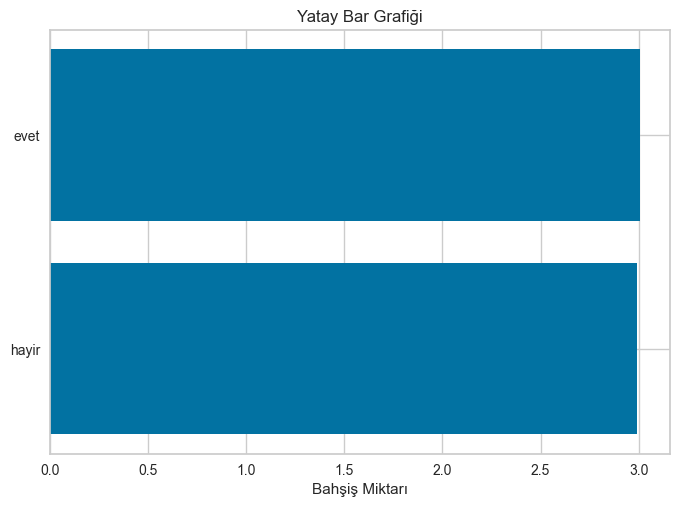

In [13]:
plt.figure()          # Yeni bir grafik figürü oluştur

#Yatay çubuk grafiği çiz
plt.barh(y=ozet.index, width=ozet.values, color="b")
      # - 'y=ozet.index'  Çubukların kategorik değerleri (sigara içme durumu gibi).
      # - 'width=ozet.values'  Çubukların uzunluğu (bahşiş miktarları).
      # - 'color="b"'  Çubukların rengi mavi ("b") olarak ayarlanır.

plt.xlabel("Bahşiş Miktarı")     # X eksenine etiket ekle
plt.title("Yatay Bar Grafiği")  # Grafiğe başlık ekle
plt.show()

### **1.4.3 Pasta Grafiği (Pie Chart)**

**Örnek:** Güne göre toplam bahşiş miktarını gösteren pasta grafiği.

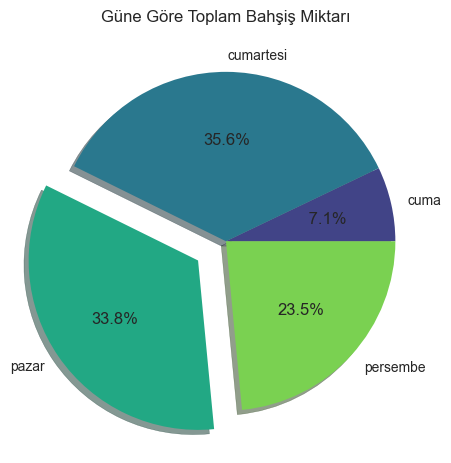

In [14]:
# "gun" sütununa göre gruplandırarak her gündeki toplam bahşiş miktarını hesapla
ozet_gun = tips_df.groupby("gun", observed=True)["bahsis"].sum()
        # - 'groupby("gun")'  Veriyi günlere göre gruplar.
        # - '["bahsis"].sum()'  Her gün için bahşiş miktarlarının toplamını hesaplar.

etiketler = ozet_gun.index  # Pasta grafiği için gün isimlerini etiket olarak al
degerler = ozet_gun.values  # Pasta dilimlerinin büyüklüğünü belirlemek için bahşiş miktarlarını al
renkler = sns.color_palette("viridis", len(etiketler))  # Renk paleti oluştur
explode_vals = [0] * len(etiketler)  # Başlangıçta tüm dilimleri patlatma (normal göster)


# Eğer en az 3 gün varsa, üçüncü dilimi patlat (grafikte öne çıkarmak için)
if len(etiketler) >= 3:
    explode_vals[2] = 0.2  # 3. dilimi biraz dışarı çıkar

plt.figure()  # Yeni bir grafik figürü oluştur

plt.pie(
    degerler,               # Pasta dilimlerinin büyüklüğü
    explode=explode_vals,   # Hangi dilimler öne çıkarılacak (explode effect)
    labels=etiketler,       # Dilimlerin etiketleri (Gün isimleri)
    autopct="%4.1f%%",      # Dilimlerin yüzdesini göster
    shadow=True,            # Gölgeli efekt ekle
    startangle=360,         # Grafiği 360 dereceden başlat
    colors=renkler          # Dilimler için renk paletini uygula
)

plt.title("Güne Göre Toplam Bahşiş Miktarı")  # Grafiğe başlık ekle
plt.show()

### **1.4.4 Serpilme/Dağılım Plot (Scatter Plot)**

**Örnek 1:** Toplam hesap ile bahşiş arasındaki ilişki.

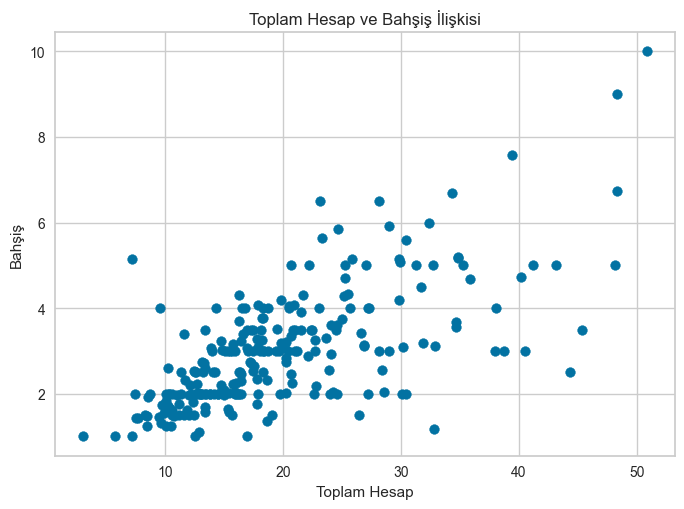

In [15]:
plt.figure()  # Yeni bir grafik figürü oluştur

#Toplam hesap ve bahşiş arasındaki ilişkiyi gösteren saçılım grafiği (scatter plot) çiz.
plt.scatter(tips_df["toplamHesap"], tips_df["bahsis"])
      # - 'tips_df["toplamHesap"]'  X ekseni için toplam hesap verileri.
      # - 'tips_df["bahsis"]'  Y ekseni için bahşiş verileri.
      # - 'plt.scatter()'  Her bir veri noktasını bir nokta olarak çizer.

plt.xlabel("Toplam Hesap")          # X ekseni etiketini belirle
plt.ylabel("Bahşiş")               # Y ekseni etiketini belirle
plt.title("Toplam Hesap ve Bahşiş İlişkisi")   # Grafiğe başlık ekle
plt.show()

**Örnek 2:** Toplam hesap ve bahşiş miktarı (Sigara Durumuna Göre)

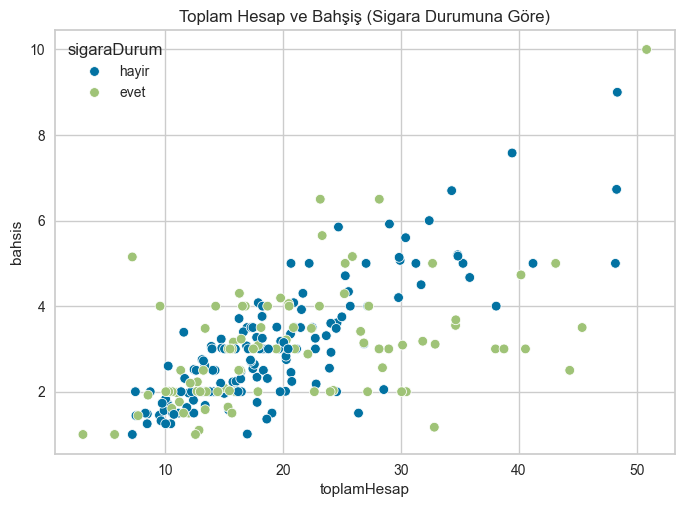

In [16]:
plt.figure()  # Yeni bir grafik figürü oluştur

# Toplam hesap ve bahşiş arasındaki ilişkiyi gösteren saçılım grafiği çiz (Seaborn kullanarak).
sns.scatterplot(x="toplamHesap", y="bahsis", hue="sigaraDurum", data=tips_df)
      # - 'x="toplamHesap"'  X eksenine toplam hesap sütunu yerleştirilir.
      # - 'y="bahsis"'  Y eksenine bahşiş sütunu yerleştirilir.
      # - 'hue="sigaraDurum"'  Sigara durumuna göre noktaların rengi belirlenir.
      # - 'data=tips_df'  Verinin hangi veri çerçevesinden alınacağını belirtir.

plt.title("Toplam Hesap ve Bahşiş (Sigara Durumuna Göre)")
plt.show()

**Örnek 3:** Seçili müşterilerin toplam hesap ve bahşiş **miktarı**

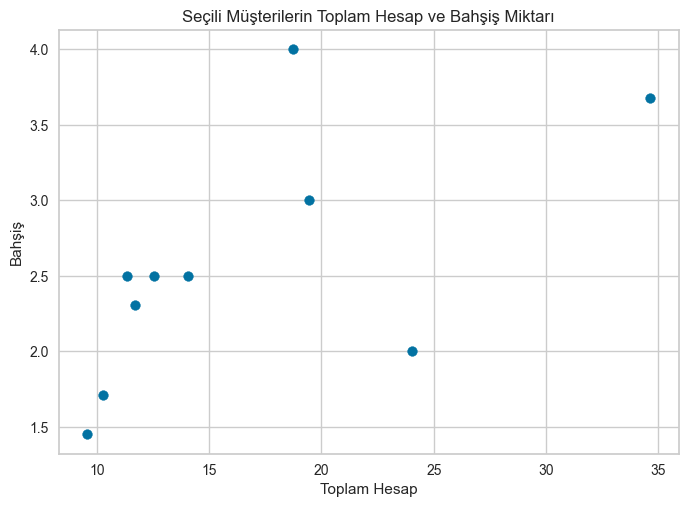

In [17]:
# Seçili müşterilerin indeks numaralarını içeren liste oluştur
secim = [200, 150, 100, 50, 10, 180, 120, 80, 30, 230]

# Seçilen indekslerin veri çerçevesinin sınırlarını aşmadığından emin olmak için filtreleme yap
secim = [i for i in secim if i < len(tips_df)]
        # - 'if i < len(tips_df)'  Eğer indeks değeri toplam satır sayısını aşarsa çıkarılır.
        # - Bu işlem, "IndexError" hatasını önlemek için yapılır.

# Seçili müşterilerin toplam hesap ve bahşiş bilgilerini içeren alt veri kümesi oluştur.
altkume = tips_df.iloc[secim][["toplamHesap", "bahsis"]]
        # - 'tips_df.iloc[secim]'  Seçili indekslere göre satırları alır.
        # - '[["toplamHesap", "bahsis"]]'  Sadece bu iki sütunu seçer.

plt.figure()  # Yeni bir grafik figürü oluştur

# Seçili müşterilerin toplam hesap ve bahşiş arasındaki ilişkiyi gösteren saçılım grafiği çiz.
plt.scatter(altkume["toplamHesap"], altkume["bahsis"])

plt.xlabel("Toplam Hesap")
plt.ylabel("Bahşiş")
plt.title("Seçili Müşterilerin Toplam Hesap ve Bahşiş Miktarı")
plt.show()

#### **1.4.5 Histogram**

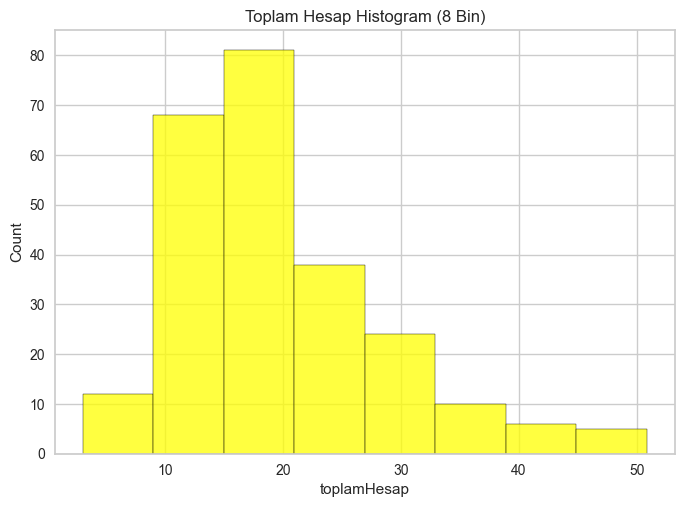

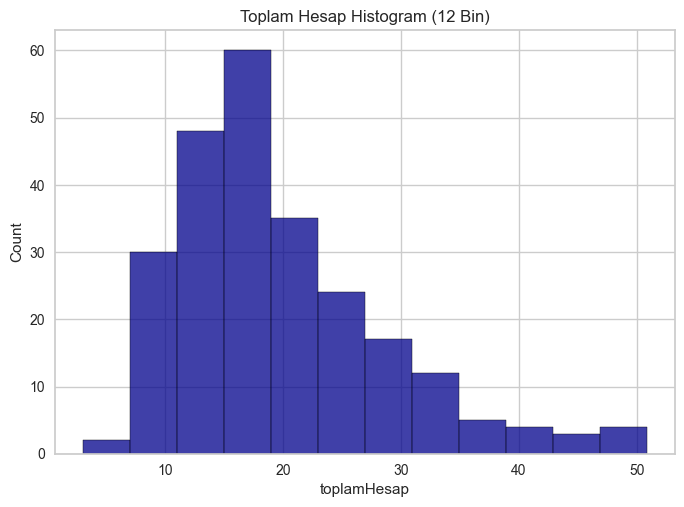

Toplam Hesap için describe:
count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: toplamHesap, dtype: float64


In [18]:
plt.figure()
# Toplam hesap dağılımını gösteren histogram (8 bin)
sns.histplot(data=tips_df, x="toplamHesap", color="yellow", bins=8)
        # - 'data=tips_df'       Veriyi seçer.
        # - 'x="toplamHesap"'    X ekseninde toplam hesap değerleri kullanılır.
        # - 'color="yellow"'     Histogram sarı renkte çizilir.
        # - 'bins=8'             8 aralıklı bin (sütun) oluşturur.

plt.title("Toplam Hesap Histogram (8 Bin)")
plt.show()


plt.figure()
# Toplam hesap dağılımını gösteren histogram (12 bin)
sns.histplot(data=tips_df, x="toplamHesap", color="darkblue", bins=12)
        # - 'color="darkblue"'   Histogram koyu mavi renkte çizilir.
        # - 'bins=12'            12 aralıklı bin (sütun) oluşturur.

plt.title("Toplam Hesap Histogram (12 Bin)")
plt.show()


# Toplam hesap değişkeninin tanımlayıcı istatistiklerini ekrana yazdır
print("Toplam Hesap için describe:")
print(tips_df["toplamHesap"].describe())
        # - 'describe()'         Ortalama, min, max, standart sapma gibi istatistikleri gösterir.